# Gradient Boosting Decision Tree (GBDT)

Gradient-boosting differs from AdaBoost due to the following reason:
-  instead of assigning weights to specific samples, GBDT will fit a decision tree on the residuals error (hence the name "gradient") of the previous tree. 
- Therefore, each new tree in the ensemble predicts the error made by the previous learner instead of predicting the target directly.

In [2]:
import numpy as np
import pandas as pd

rng = np.random.RandomState(0)\

def generate_data(n_samples=50):
    x_max, x_min = 1.4, -1.4
    len_x = x_max - x_min
    x = rng.rand(n_samples) * len_x - len_x / 2
    noise = rng.randn(n_samples) * 0.3
    y = x**3 - 0.5 * x**2 + noise

    data_train = pd.DataFrame(x, columns=["Feature"])
    data_test = pd.DataFrame(
        np.linspace(x_max, x_min, num=300), columns=["Feature"]
    )
    target_train = pd.Series(y, name="Target")

    return data_train, data_test, target_train


data_train, data_test, target_train = generate_data() 

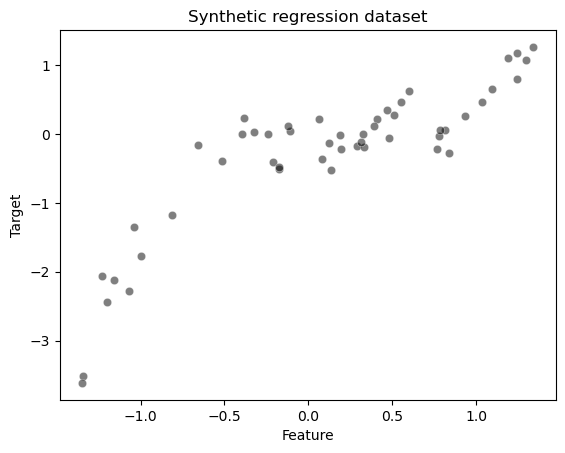

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
_ = plt.title("Synthetic regression dataset")

 boosting will be based on assembling a sequence of learners

In [4]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3, random_state=0)
tree.fit(data_train, target_train)

target_train_predicted = tree.predict(data_train)
target_test_predicted = tree.predict(data_test)

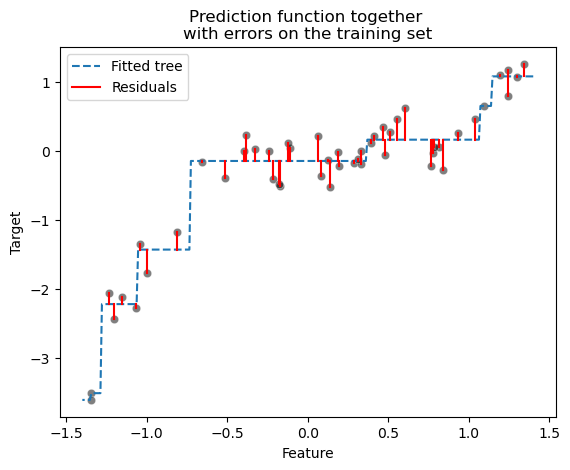

In [5]:
# plot the data
sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
# plot the predictions
line_predictions = plt.plot(data_test["Feature"], target_test_predicted, "--")

# plot the residuals
for value, true, predicted in zip(
    data_train["Feature"], target_train, target_train_predicted
):  
    lines_residuals = plt.plot([value, value], [true, predicted], color="red")

plt.legend(
    [line_predictions[0], lines_residuals[0]], ["Fitted tree", "Residuals"]
)
_ = plt.title("Prediction function together \nwith errors on the training set")

- Since the tree underfits the data, its accuracy is far from perfect on the training data. We can observe this in the figure by looking at the difference between the predictions and the ground-truth data. We represent these errors, called "Residuals", by unbroken red lines.
- In a gradient-boosting algorithm, the idea is to create a second tree which, given the same data data, will try to predict the residuals instead of the vector target. We would therefore have a tree that is able to predict the errors made by the initial tree.

In [6]:
residuals = target_train - target_train_predicted

tree_residuals = DecisionTreeRegressor(max_depth=5, random_state=0)
tree_residuals.fit(data_train, residuals)

target_train_predicted_residuals = tree_residuals.predict(data_train)
target_test_predicted_residuals = tree_residuals.predict(data_test)

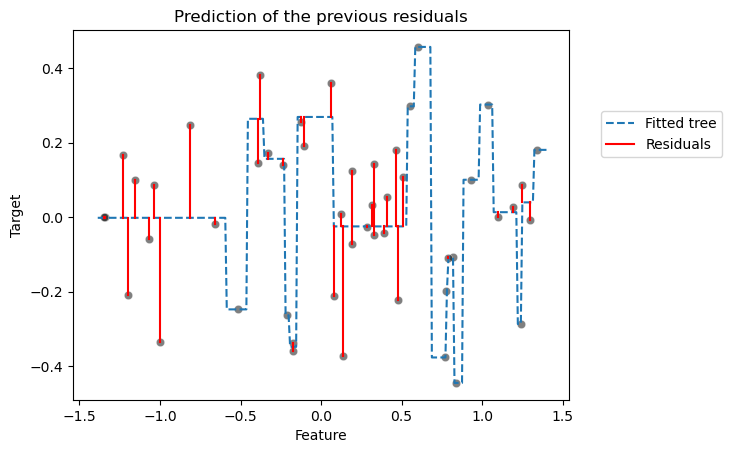

In [7]:
sns.scatterplot(x=data_train["Feature"], y=residuals, color="black", alpha=0.5)
line_predictions = plt.plot(
    data_test["Feature"], target_test_predicted_residuals, "--"
)

# plot the residuals of the predicted residuals
for value, true, predicted in zip(
    data_train["Feature"], residuals, target_train_predicted_residuals
):
    lines_residuals = plt.plot([value, value], [true, predicted], color="red")

plt.legend(
    [line_predictions[0], lines_residuals[0]],
    ["Fitted tree", "Residuals"],
    bbox_to_anchor=(1.05, 0.8),
    loc="upper left",
)
_ = plt.title("Prediction of the previous residuals")

In [8]:
sample = data_train.iloc[[-2]]
x_sample = sample["Feature"].iloc[0]
target_true = target_train.iloc[-2]
target_true_residual = residuals.iloc[-2]

- Let's plot the previous information and highlight our sample of interest.
- Let's start by plotting the original data and the prediction of the first decision tree.

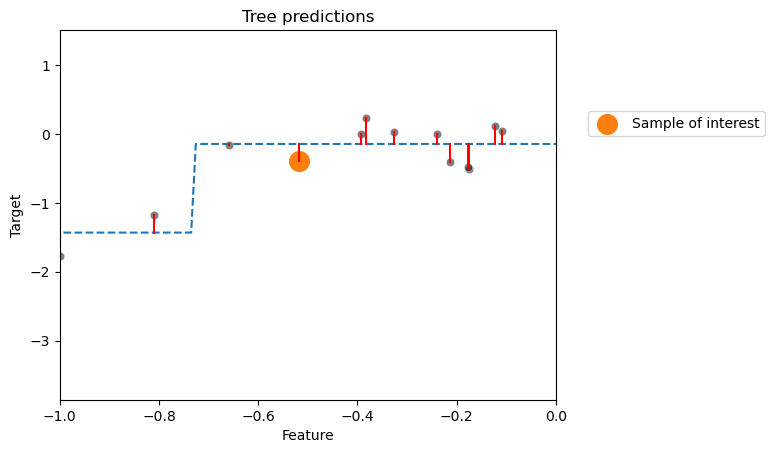

In [9]:
# Plot the previous information:
#   * the dataset
#   * the predictions
#   * the residuals

sns.scatterplot(
    x=data_train["Feature"], y=target_train, color="black", alpha=0.5
)
plt.plot(data_test["Feature"], target_test_predicted, "--")
for value, true, predicted in zip(
    data_train["Feature"], target_train, target_train_predicted
):
    lines_residuals = plt.plot([value, value], [true, predicted], color="red")

# Highlight the sample of interest
plt.scatter(
    sample, target_true, label="Sample of interest", color="tab:orange", s=200
)
plt.xlim([-1, 0])
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Tree predictions")

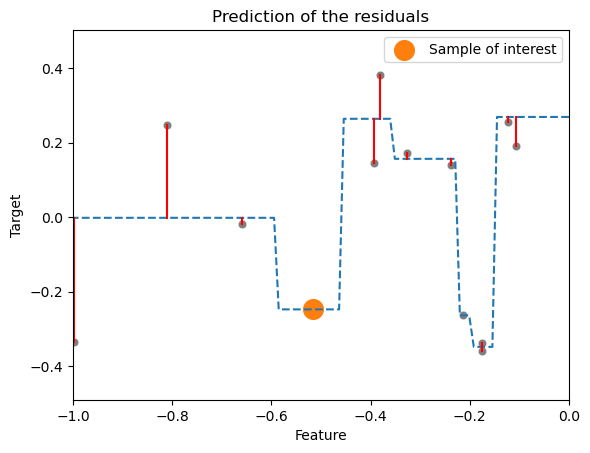

In [10]:
# Plot the previous information:
#   * the residuals committed by the first tree
#   * the residual predictions
#   * the residuals of the residual predictions

sns.scatterplot(x=data_train["Feature"], y=residuals, color="black", alpha=0.5)
plt.plot(data_test["Feature"], target_test_predicted_residuals, "--")
for value, true, predicted in zip(
    data_train["Feature"], residuals, target_train_predicted_residuals
):
    lines_residuals = plt.plot([value, value], [true, predicted], color="red")

# Highlight the sample of interest
plt.scatter(
    sample,
    target_true_residual,
    label="Sample of interest",
    color="tab:orange",
    s=200,
)
plt.xlim([-1, 0])
plt.legend()
_ = plt.title("Prediction of the residuals")

In [11]:
print(f"True value to predict for f(x={x_sample:.3f}) = {target_true:.3f}")

y_pred_first_tree = tree.predict(sample)[0]
print(
    f"Prediction of the first decision tree for x={x_sample:.3f}: "
    f"y={y_pred_first_tree:.3f}"
)
print(f"Error of the tree: {target_true - y_pred_first_tree:.3f}")

True value to predict for f(x=-0.517) = -0.393
Prediction of the first decision tree for x=-0.517: y=-0.145
Error of the tree: -0.248


In [12]:
print(
    f"Prediction of the residual for x={x_sample:.3f}: "
    f"{tree_residuals.predict(sample)[0]:.3f}"
)

Prediction of the residual for x=-0.517: -0.248


In [13]:
y_pred_first_and_second_tree = (
    y_pred_first_tree + tree_residuals.predict(sample)[0]
)
print(
    "Prediction of the first and second decision trees combined for "
    f"x={x_sample:.3f}: y={y_pred_first_and_second_tree:.3f}"
)
print(f"Error of the tree: {target_true - y_pred_first_and_second_tree:.3f}")

Prediction of the first and second decision trees combined for x=-0.517: y=-0.393
Error of the tree: 0.000


- one needs to add several trees to the ensemble to successfully correct the error (i.e. the second tree corrects the first tree's error, while the third tree corrects the second tree's error and so on).

In [14]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_validate

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(n_estimators=200)
cv_results_gbdt = cross_validate(
    gradient_boosting,
    data,
    target,
    scoring="neg_mean_absolute_error",
    n_jobs=2,
)

In [16]:
print("Gradient Boosting Decision Tree")
print(
    "Mean absolute error via cross-validation: "
    f"{-cv_results_gbdt['test_score'].mean():.3f} ± "
    f"{cv_results_gbdt['test_score'].std():.3f} k$"
)
print(f"Average fit time: {cv_results_gbdt['fit_time'].mean():.3f} seconds")
print(
    f"Average score time: {cv_results_gbdt['score_time'].mean():.3f} seconds"
)

Gradient Boosting Decision Tree
Mean absolute error via cross-validation: 46.385 ± 2.912 k$
Average fit time: 19.246 seconds
Average score time: 0.020 seconds


In [17]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(n_estimators=200, n_jobs=2)
cv_results_rf = cross_validate(
    random_forest,
    data,
    target,
    scoring="neg_mean_absolute_error",
    n_jobs=2,
)

In [18]:
print("Random Forest")
print(
    "Mean absolute error via cross-validation: "
    f"{-cv_results_rf['test_score'].mean():.3f} ± "
    f"{cv_results_rf['test_score'].std():.3f} k$"
)
print(f"Average fit time: {cv_results_rf['fit_time'].mean():.3f} seconds")
print(f"Average score time: {cv_results_rf['score_time'].mean():.3f} seconds")

Random Forest
Mean absolute error via cross-validation: 46.693 ± 4.679 k$
Average fit time: 65.123 seconds
Average score time: 0.348 seconds


- In term of computation performance, the forest can be parallelized and will benefit from using multiple cores of the CPU. 
- In terms of scoring performance, both algorithms lead to very close results.
- gradient boosting is a very fast algorithm to predict compared to random forest. This is due to the fact that gradient boosting uses shallow trees. 